# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

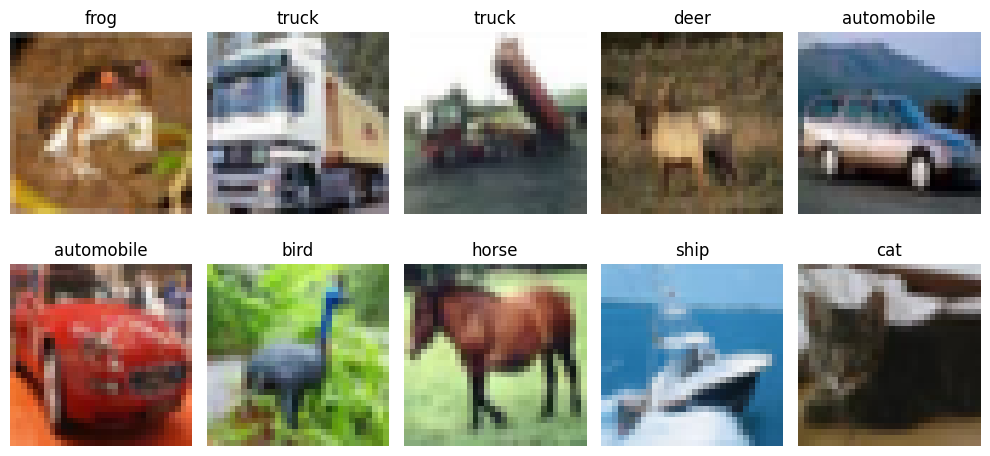

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
#  ANN (original - 2 hidden layers, 10 epochs)
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

c:\Users\LOQ\.conda\envs\ml_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.2646 - loss: 1.9995 - val_accuracy: 0.3494 - val_loss: 1.8387
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3107 - loss: 1.8757 - val_accuracy: 0.3490 - val_loss: 1.8082
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3353 - loss: 1.8211 - val_accuracy: 0.3720 - val_loss: 1.7625
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3510 - loss: 1.7797 - val_accuracy: 0.3870 - val_loss: 1.7346
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3612 - loss: 1.7546 - val_accuracy: 0.4010 - val_loss: 1.6952
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3702 - loss: 1.7322 - val_accuracy: 0.3816 - val_loss: 1.7351
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3764 - loss: 1.7224 - val_accuracy: 0.4030 - val_loss: 1.6736
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3720 - loss: 1.7253 - val_accuracy: 0

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4219 - loss: 1.6552
ANN Test Accuracy: 0.4219000041484833


## Task 1 (MORE LAYERS IN ANN)

In [7]:
# Task 1: Deeper ANN with more Dense layers
ann_model_v2 = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_v2_history = ann_model_v2.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

ann_v2_test_loss, ann_v2_test_acc = ann_model_v2.evaluate(x_test_flat, y_test)
print("Deeper ANN Test Accuracy:", ann_v2_test_acc)
print("Baseline ANN Test Accuracy:", ann_test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.2365 - loss: 2.0479 - val_accuracy: 0.2918 - val_loss: 1.9031
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.2944 - loss: 1.9153 - val_accuracy: 0.3310 - val_loss: 1.8682
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3194 - loss: 1.8598 - val_accuracy: 0.3394 - val_loss: 1.8366
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3298 - loss: 1.8297 - val_accuracy: 0.3538 - val_loss: 1.7800
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3394 - loss: 1.8010 - val_accuracy: 0.3508 - val_loss: 1.7820
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3521 - loss: 1.7818 - val_accuracy: 0.3864 - val_loss: 1.7505
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3578 - loss: 1.7626 - val_accuracy: 0.3960 - val_loss: 1.7058
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3687 - loss: 1.7407 - val_accu

## Task 2 : 20 epochs

In [8]:
# Task 3 (ANN): Original architecture, trained for 20 epochs
ann_model_20ep = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_20ep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_20ep_history = ann_model_20ep.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

ann_20ep_test_loss, ann_20ep_test_acc = ann_model_20ep.evaluate(x_test_flat, y_test)
print("ANN 20 Epochs Test Accuracy:", ann_20ep_test_acc)
print("Baseline ANN (10 epochs) Test Accuracy:", ann_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.2637 - loss: 2.0041 - val_accuracy: 0.3344 - val_loss: 1.8506
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3196 - loss: 1.8589 - val_accuracy: 0.3722 - val_loss: 1.7610
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3391 - loss: 1.8078 - val_accuracy: 0.4048 - val_loss: 1.7149
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3535 - loss: 1.7769 - val_accuracy: 0.3918 - val_loss: 1.7037
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3622 - loss: 1.7530 - val_accuracy: 0.3950 - val_loss: 1.7042
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3701 - loss: 1.7324 - val_accuracy: 0.4188 - val_loss: 1.6722
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3754 - loss: 1.7145 - val_accuracy: 0.4156 - val_loss: 1.6657
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3789 - loss: 1.7016 - val_accuracy: 

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [9]:
# Baseline CNN (original - 32->64->128 filters, 10 epochs)
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

c:\Users\LOQ\.conda\envs\ml_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.4688 - loss: 1.4867 - val_accuracy: 0.5828 - val_loss: 1.1768
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6118 - loss: 1.1129 - val_accuracy: 0.6124 - val_loss: 1.1182
Epoch 3/10
472/704 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6656 - loss: 0.9573

KeyboardInterrupt: 

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7122 - loss: 1.0090
CNN Test Accuracy: 0.7121999859809875


## Task 2 increased filters 

In [ ]:
# Task 2: CNN with scaled-up filters (64 -> 128 -> 256)
cnn_model_v2 = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_v2_history = cnn_model_v2.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

cnn_v2_test_loss, cnn_v2_test_acc = cnn_model_v2.evaluate(x_test_norm, y_test)
print("Scaled Filters CNN (64-128-256), 10 epochs, Test Accuracy:", cnn_v2_test_acc)
print("Baseline CNN (32-64-128), 10 epochs, Test Accuracy:", cnn_test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.4485 - loss: 1.5415 - val_accuracy: 0.4656 - val_loss: 1.5521
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.5952 - loss: 1.1606 - val_accuracy: 0.6412 - val_loss: 1.0211
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.6680 - loss: 0.9615 - val_accuracy: 0.6148 - val_loss: 1.1568
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.7127 - loss: 0.8303 - val_accuracy: 0.6562 - val_loss: 1.0099
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.7554 - loss: 0.7124 - val_accuracy: 0.6876 - val_loss: 0.9436
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.7874 - loss: 0.6102 - val_accuracy: 0.6916 - val_loss: 1.0858
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.8154 - loss: 0.5215 - val_accuracy: 0.7114 - val_loss: 0.9463
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.8438 - loss: 0.4527 - 

## Task 3 20 epochs

In [ ]:
# Task 3 (CNN): Original filters (32->64->128), epochs increased to 20
cnn_model_20ep = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_20ep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_20ep_history = cnn_model_20ep.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

cnn_20ep_test_loss, cnn_20ep_test_acc = cnn_model_20ep.evaluate(x_test_norm, y_test)
print("CNN 20 Epochs (original filters) Test Accuracy:", cnn_20ep_test_acc)
print("Baseline CNN (10 epochs) Test Accuracy:", cnn_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.4555 - loss: 1.5268 - val_accuracy: 0.3366 - val_loss: 2.1129
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5993 - loss: 1.1449 - val_accuracy: 0.4876 - val_loss: 1.5864
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6652 - loss: 0.9641 - val_accuracy: 0.6320 - val_loss: 1.0648
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.7059 - loss: 0.8413 - val_accuracy: 0.6614 - val_loss: 0.9939
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7390 - loss: 0.7457 - val_accuracy: 0.7026 - val_loss: 0.8576
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7684 - loss: 0.6662 - val_accuracy: 0.6846 - val_loss: 0.9255
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7892 - loss: 0.5922 - val_accuracy: 0.7190 - val_loss: 0.8482
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8098 - loss: 0.5385 - 

## Early stopping 

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Task 4: CNN with EarlyStopping
cnn_model_es = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_es_history = cnn_model_es.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_es_test_loss, cnn_es_test_acc = cnn_model_es.evaluate(x_test_norm, y_test)
print("CNN with EarlyStopping Test Accuracy:", cnn_es_test_acc)
print("Number of epochs actually run:", len(cnn_es_history.history['loss']))

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.4578 - loss: 1.5229 - val_accuracy: 0.3576 - val_loss: 1.8204
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5946 - loss: 1.1575 - val_accuracy: 0.6262 - val_loss: 1.0726
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6614 - loss: 0.9783 - val_accuracy: 0.6432 - val_loss: 1.0179
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7011 - loss: 0.8559 - val_accuracy: 0.6658 - val_loss: 1.0027
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7348 - loss: 0.7621 - val_accuracy: 0.6936 - val_loss: 0.8830
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7651 - loss: 0.6760 - val_accuracy: 0.6850 - val_loss: 0.9710
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7862 - loss: 0.6083 - val_accuracy: 0.7160 - val_loss: 0.8688
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8067 - loss: 0.5456 - 

# 🚀 Training Strategy Upgrade: Data Augmentation     

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])


aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)
print("Baseline CNN Test Accuracy:", cnn_test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.3755 - loss: 1.7132 - val_accuracy: 0.4778 - val_loss: 1.4520
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4745 - loss: 1.4683 - val_accuracy: 0.5352 - val_loss: 1.2841
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5090 - loss: 1.3744 - val_accuracy: 0.5638 - val_loss: 1.2163
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5299 - loss: 1.3229 - val_accuracy: 0.5782 - val_loss: 1.1896
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5483 - loss: 1.2703 - val_accuracy: 0.5968 - val_loss: 1.1307
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5634 - loss: 1.2407 - val_accuracy: 0.5796 - val_loss: 1.2395
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5708 - loss: 1.2164 - val_accuracy: 0.6216 - val_loss: 1.0553
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5800 - loss: 1.1898 - val_acc

 ## 📈 Compare Learning Curves


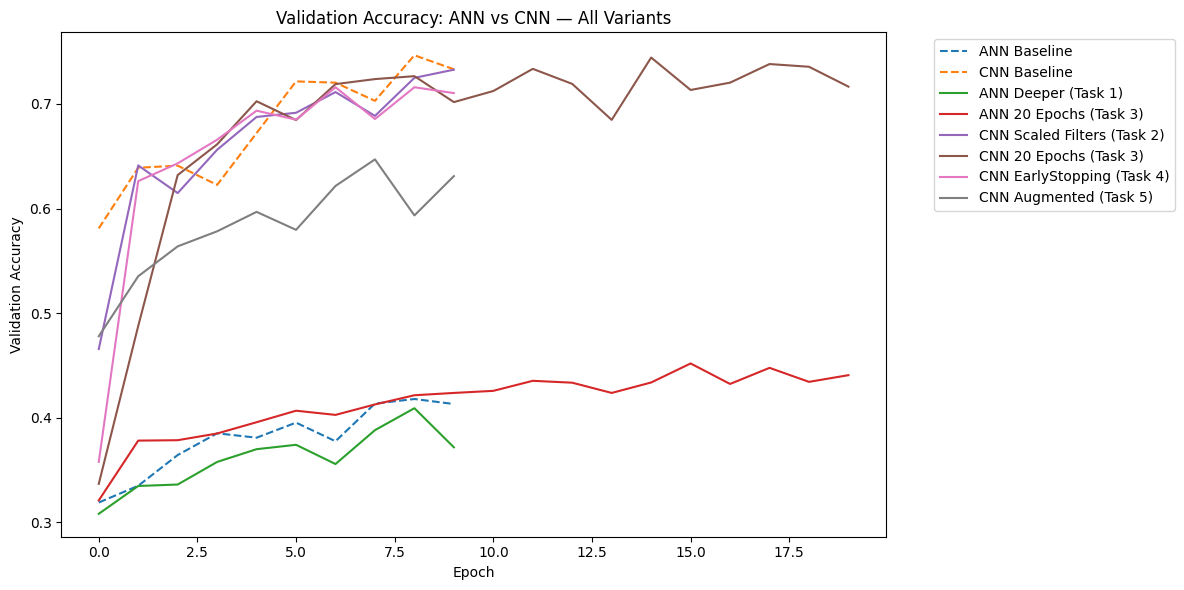

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(ann_history.history['val_accuracy'], label='ANN Baseline', linestyle='--')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Baseline', linestyle='--')

plt.plot(ann_v2_history.history['val_accuracy'], label='ANN Deeper (Task 1)')
plt.plot(ann_20ep_history.history['val_accuracy'], label='ANN 20 Epochs (Task 3)')

plt.plot(cnn_v2_history.history['val_accuracy'], label='CNN Scaled Filters (Task 2)')
plt.plot(cnn_20ep_history.history['val_accuracy'], label='CNN 20 Epochs (Task 3)')
plt.plot(cnn_es_history.history['val_accuracy'], label='CNN EarlyStopping (Task 4)')
plt.plot(aug_history.history['val_accuracy'], label='CNN Augmented (Task 5)')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy: ANN vs CNN — All Variants")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "ANN Baseline", "ANN Deeper (Task 1)", "ANN 20 Epochs (Task 3)",
        "CNN Baseline", "CNN Scaled Filters (Task 2)", "CNN 20 Epochs (Task 3)",
        "CNN EarlyStopping (Task 4)", "CNN Augmented (Task 5)"
    ],
    "Test Accuracy": [
        ann_test_acc, ann_v2_test_acc, ann_20ep_test_acc,
        cnn_test_acc, cnn_v2_test_acc, cnn_20ep_test_acc,
        cnn_es_test_acc, aug_test_acc
    ]
})
comparison = comparison.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
comparison

,Model,Test Accuracy
0,CNN Scaled Filters (Task 2),0.7222
1,CNN EarlyStopping (Task 4),0.7159
2,CNN Baseline,0.7122
3,CNN 20 Epochs (Task 3),0.7072
4,CNN Augmented (Task 5),0.6337
5,ANN 20 Epochs (Task 3),0.4455
6,ANN Baseline,0.4189
7,ANN Deeper (Task 1),0.3800


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**